# Ribbon Model on Elastica
Author: Pierre Maillard *pierre.maillard@epfl.ch*\
Release date: 28.05.2025

This python notebook is a guide to use elastica to solve simple load cases simulation of a 1D ribbon model developped by Basile Audoly and Sebastien Neukirch in *"A one-dimensional model for elastic ribbons: A little stretching makes a big difference"* **https://doi.org/10.1016/j.jmps.2021.104457**. 

The implementation of the model and all the specific functions related to the ribbon model were hard coded direclty inside of a merge code between the **elastica** source code and a modified version of **elastica** by Arman Tekinalp developped for this work: *Topology, dynamics, and control of a muscle-architected soft arm* (**https://doi.org/10.1073/pnas.2318769121**).\
We use the source code of **elastica** that was available on February 2025 on the *github* page of GazzolaLab: **https://github.com/GazzolaLab/PyElastica** \
And Arman Tekinalp modified version available here: **https://github.com/GazzolaLab/topology-dynamics-control-of-a-muscle-architected-soft-arm** \
As the source-code of elastica has been modified and adapted, **DO NOT** install pyelastica direclty. You should be able to use directly the source code without having to pre-compile/install all the **elastica** 'library'.

If you need to change a function related to the behavior of the ribbon or the solver. Go directly inside of the source code of **elastica** available with this notebook and follow the **user_guide_ribbon_simulation.pdf** to find to portion of code you need. Every post-processing and plotting function are define inside of the **src_plotting_ribbon.py** script. All informations related to the flow of data is described on the **user_guide_ribbon_simulation.pdf**.

In [ ]:
#if you need to install the libraries just run this line
#%pip install -U -r requirements.txt

In [2]:
from elastica import *
from elastica.rod.ribbon1D import Ribbon1D
from elastica.rod.linear_ribbon1D import LinearRibbon1D

from elastica._linalg import _batch_norm
from elastica._linalg import _batch_cross

import os
import pickle
import numpy as np
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "notebook"

import pandas as pd
from collections import defaultdict
from matplotlib import pyplot as plt
from elastica.src_plotting_ribbon import *
from create_sim_env import *

## Simulation initialization: Torsional buckling case

This section will go through all of the step to run a simulation using elastica for a specific load case. Here we will focus on the torsional buckling case that we will use to validate the ribbon model by comparing it with Auto-07p simulations.

The first step is to setup the simulation class and add every object and behavior that we want to consider. This is the place where you choose the kind of model you want to use for the ribbon, the boundary conditions, damping and forces you want to add. Exept the ribbon objects *Ribbon1D.straight_ribbon* and *LinearRibbon1D.straight_ribbon*, all objects used in this sections are directly from the **elastica** library (not implemented by Pierre Maillard) so please refer to **pyelastica** documentation for informations if needed. **https://docs.cosseratrods.org/en/latest/**

In [3]:
#First we create the class that will contains all of the objects and physical behavior
class Ribbon(BaseSystemCollection, Contact, Forcing, Constraints, CallBacks, Damping):
        pass
Ribbon_sim = Ribbon()

### Here we define all of the constants that describ the ribbon material and geometry at the start of the simulation ###

start = np.array([0.0, 0.0, 0.0])     #position of the first node
direction = np.array([1.0, 0.0, 0.0]) #direction of the centerline (d3) at the first node
normal = np.array([0.0, 1.0, 0.0])    #normal of the centerline (d1) at the first node

L = 50           # total length [mm]
thickness = 0.5  # thickness [mm] (is 5 times to big because of computation time issue, this is not the case for other analysis)
width = 5.0      # width [mm]

density = 1.017e-7 # density [g/mm^3] (100 times heavier to stabilize the numerical solver)
nu = 3e1           # damping constant [N*s/mm] (non physical because tuned to speed up the stabilization of the solution at steady stat)

E = 2.77e3                              # Young's modulus [N/mm^2]
poisson_ratio = 0.34                    # Poisson's ratio [-]
shear_modulus = E/(2*(1+poisson_ratio)) # Shear modulus for isotropic material [N/mm^2]

num_lagrange = 1e2   # ratio between the stiefness of the centerline (extensibility and shearability) and the stiefness of the bending modes
                     # Try to keep it as high as possible to assure the centerline "inextensibility" and "unshearability"
                     # See the "sanity_check_plot" in the post-processing for more informations.

dt = 1.25e-7         # time step [s] This needs to be tune by hand to keep stability. (see user_guide_ribbon_simulation.pdf for more informations)
final_time = 0.75    # final time [s] The final simulation time must be long enough to ensure that a stable state is reached.
                     # See the "Sanity and Convergence check" in the post-processing section for more informations.


force_adimentional = np.array([0.0, 0.15, 15]) #correspond to the adimentional force set inside AUTO-07P

# compute the tip force in Newton. This can be impose directly if you need to choose the force in Newton direclty
tip_force = force_adimentional * (E * width * thickness**3 / 12 / L**2) 
print(f"The force apply at the tip on the laboratory frame is define as {tip_force} [N]")
ramp_up_time = 0.05 # force ramp time [s] can be increase if the transision bewteen no force, final force is to sharp.
                    # This value should not be modified too much, as it indirectly requires an increase in the final time.
                    # Uselly the simulations will blow up because of internal stress and not really because of a fast force ramp.



n_elem = 50  #number of element used to discretize the ribbon


# to choose the model for the ribbon. For now because we merge the codes, only the elastic ribbon works. 
ribbon_model = 'elastic'  


#elastic model developped by B.Audoly and S.Neukirch
if ribbon_model=="elastic":
    filename = "elastic_ribbon"
    ribbon = Ribbon1D.straight_ribbon(
        n_elem,
        start,
        direction,
        normal,
        L,
        thickness,
        width,
        density,
        youngs_modulus=E,
        shear_modulus=E*num_lagrange, # influence the shearability of the ribbon
        poisson_ratio=0.34,
    )

#cosserat rod but with a rectangular cross section
elif ribbon_model == 'linear':
    filename = "linear_ribbon"
    ribbon = LinearRibbon1D.straight_ribbon(
        n_elem,
        start,
        direction,
        normal,
        L,
        thickness,
        width,
        density,
        youngs_modulus=E,
        shear_modulus=shear_modulus,
        poisson_ratio = poisson_ratio,
    )

#cosserat rod with radius = thickness
else:
    filename = "elastic_rod"
    ribbon = CosseratRod.straight_rod(
        n_elem,
        start,
        direction,
        normal,
        L,
        thickness,
        density,
        nu,
        youngs_modulus=E,
        shear_modulus=shear_modulus,
        poisson_ratio = poisson_ratio,
    )

Ribbon_sim.append(ribbon)    


""" Add damping """
Ribbon_sim.dampen(ribbon).using(
    AnalyticalLinearDamper,
    damping_constant=nu,
    time_step=dt,
)

    
# When tested, it impact steady state !!! Then adding error when comparing with auto
#Rod.dampen(ribbon).using(
#         LaplaceDissipationFilter,
#         filter_order=4,   # order of the filter (geater order means less damping)
#    )


""" Set up boundary conditions """
Ribbon_sim.constrain(ribbon).using(
    GeneralConstraint,
    constrained_position_idx=(0,), #to controle the BC at the base
    constrained_director_idx=(0,), #to controle the BC at the base
    translational_constraint_selector= np.array([True, True, True]) , # Fix all displacement
    rotational_constraint_selector=np.array([True, True, True])  # Fix all rotations
)


""" Add forcing at the tip"""
#if ramp_up_time > 0 then the force will start at 0 and go to the set force in the seted time. 
origin_force = np.array([0.0,0.0,0.0]) #force at the first node (0)
Ribbon_sim.add_forcing_to(ribbon).using(
    EndpointForces, origin_force, tip_force, ramp_up_time=ramp_up_time
)


The force apply at the tip on the laboratory frame is define as [0.         0.00865625 0.865625  ] [N]


Now we create a CallBack class that define which quantities we are gonna retrieve from the simulation at each step.

In [4]:
class RibbonCallBack(CallBackBaseClass):
    """
    Call back function for Ribbon object
    """

    def __init__(self, step_skip: int, callback_params: dict):
        CallBackBaseClass.__init__(self)
        self.every = step_skip
        self.callback_params = callback_params

    def make_callback(self, system, time, current_step: int):

        if current_step % self.every == 0:

            self.callback_params["time"].append(time)
            self.callback_params["step"].append(current_step)
            self.callback_params["position"].append(system.position_collection.copy())
            self.callback_params["velocity"].append(system.velocity_collection.copy())
            self.callback_params["curvature"].append(system.kappa.copy())
            self.callback_params["sigma"].append(system.sigma.copy())
            self.callback_params["internal_stress"].append(system.internal_stress.copy())
            self.callback_params["internal_forces"].append(system.internal_forces.copy())
            self.callback_params["external_forces"].append(system.external_forces.copy())
            self.callback_params["internal_couple"].append(system.internal_couple.copy())
            self.callback_params["directors"].append(system.director_collection.copy())
            self.callback_params["dilatation"].append(system.dilatation.copy())
            self.callback_params["tangents"].append(system.tangents.copy())
            
        
            
            return
            
#define how many steps are skip each time we retrieve/save the data.
#It is set to keep approximatly 1000 points wich is fine for the precision of the analysis and not to big to saturate the memory
step_skip= int(final_time/dt/1000)


ribbon_output_list = defaultdict(list) 
Ribbon_sim.collect_diagnostics(ribbon).using(
    RibbonCallBack, step_skip=step_skip, callback_params=ribbon_output_list
)

Then we can finalize the system. This is the step where elastica check if all of the initialization is done correclty. You will get assertion errors if some quantities are badly initialize or code error if there is something wrong with the source code.

Note that you **can not** finlalize a system twice wich means that if something is wrong in the finalization step, do some changes and then relunch the 2 last cells to recreate the simulation class entirely. 

In [5]:
Ribbon_sim.finalize()

Now we can lunch the simulation. The first time you lunch this cell (with a new kernel), it might take some times to precompile all of the numba functions but after this 5-10s wait, the number of iteration per second should be pretty constant. If the simulation diverge, the solver will stop and you will get this kind of message:

> NaN detected at step 61 in system. \
> Final time of simulation is :  1.2400000000000029e-05

This uselly means that the numerical stieffness made the simulation blow up. Follow the instruction of **user_guide_ribbon_simulation.pdf** to solve for convergence of the explicit scheme.

In [16]:
timestepper = PositionVerlet() #set the time stepper scheme. Verlet scheme is the default option provided by elastica
total_steps = int(final_time / dt) # The algoritm is run using a for loop so this is the number of step of the loop
nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)

with open("result/"+filename+"_demo_sim.pickle", 'wb') as handle:
    pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

100%|██████████| 8000000/8000000 [11:43<00:00, 11378.75it/s]

Final time of simulation is :  0.9999999996735697


## Post processing

This section will go though the post processing steps to visulalize, check converge and inspect the solution. 

We will use the solution you generated on the first section but if you want to inspect the final solutions generated from the clusters instead. Just change the path of the *.pickle* file. (ex: `result/torsional_buckling_data_5.pickle`)
The first step is to translate the data from the `defaultdict` format that elastica use to **panda** dataframe that are way easier and faster to treat, plot and work with. We also make the postion adimensional during to ease the plotting and comparhaison with **AUTO-07P** results. If you want to keep the position in [mm] just set the `base_length` parameter to 1.

In [16]:
with open("result/"+filename+"_demo_sim.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)

solution_1 = process_solution_elastica(pp_list_read, base_length=L)
solution_1

,Index_solution,time,step,s,X,Y,Z,d3x,d3y,d3z,...,e1,e2,e3,dilatation,tx,ty,tz,VX,VY,VZ
0,0,0.0,0,0.00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,0.0,0,0.02,0.020000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0.0,0,0.04,0.040000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0,0.0,0,0.06,0.060000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0,0.0,0,0.08,0.080000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51046,1000,1.0,8000000,0.92,0.494784,0.404241,0.463232,0.029263,0.514544,0.856964,...,2.089858e-07,4.267169e-07,8.042081e-07,1.000001,0.029263,0.514544,0.856965,0.000921,-0.000128,-0.000552
51047,1000,1.0,8000000,0.94,0.495369,0.414532,0.480372,0.025697,0.513204,0.857882,...,2.058267e-07,4.266460e-07,8.050502e-07,1.000001,0.025697,0.513204,0.857882,0.000944,-0.000116,-0.000559
51048,1000,1.0,8000000,0.96,0.495883,0.424796,0.497529,0.023329,0.512310,0.858484,...,2.037253e-07,4.266003e-07,8.056042e-07,1.000001,0.023329,0.512310,0.858484,0.000967,-0.000106,-0.000567
51049,1000,1.0,8000000,0.98,0.496350,0.435042,0.514699,0.022149,0.511863,0.858782,...,2.026758e-07,4.265779e-07,8.058786e-07,1.000001,0.022149,0.511863,0.858782,0.000989,-0.000093,-0.000574


Now that the data are inside of the **panda** dataframe, let's plot some important quantites to inspect the solutions.
Each solution in time has a specific integer as *indice* (0 for the first solution send by the callback function and around 1000 for the last one) so you can isolate a scpecific solution by doing: \
`solution_1[solution_1.index_solution == 10]` \
To plot the solutions we choose an array of indinces to plot, you can also add different set of solutions if you need to compare between models of boundary conditions.
You can have more details about all of the functions used in this notebook by simply printing the docstrings: `help(plot_multiple_solutions)` 

### Plot simulation quantities with respect to s

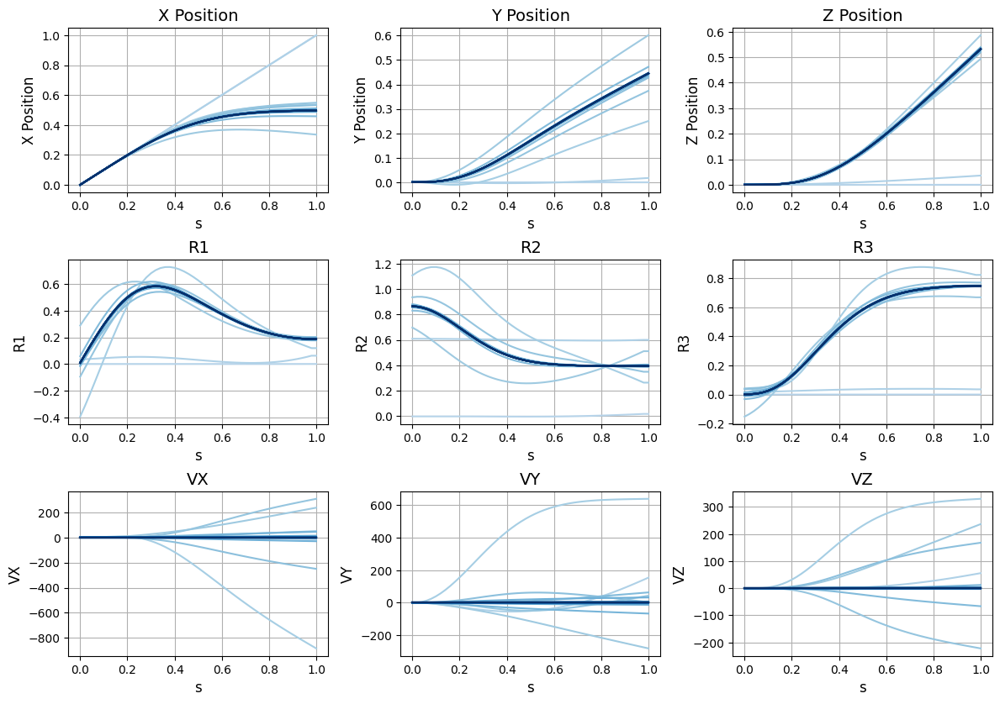

In [17]:
indices_array = np.linspace(1,solution_1.Index_solution.max(),30,dtype=np.int64)

plot_multiple_solutions(
    solution_dfs=[solution_1],
    labels=[filename],
    indices=indices_array)

### Sanity and Convergence check

To check the validity of the solution, we plot some specific quantites to check convergence and that the assumption of inextensible + unshearable centerline is well impose. Here is a exemple of a 'well-defined' solution. Here is some of the thing you should check:
- Look at the 2 'Steady State check' graphs.
    - The first one reprensent the L2 norm of the norm of the **velocity** (V) vector of all elements. (~mean measurement of the total deformation speed of the ribbon) Make sure that the velocites are small enough at the end of the simulation. Typically a L2 norm of 10e-1 would mean that if the velocity would stay constant (wich is doesn't because it decay exponentially) the mean position could deplace of 1mm if we keept simulating for an other 10 seconds. The exemple below show the pefect case where after 1.5 s we are left with only numerical noise but you do not need to go this far. (simulating only 0.75 s should be enough in my opignion).
    - The second one represent the l2 norm of the norm of the **position** (R) vector of all elements. This can futher confirm that the ribbon is indeed not moving at all after 0.75 s but keep in mind that the l2 norm could be somewhat constant even with small oscillation of the structure if the compensate with each other. (oscillating around the steady stat position)
- Look at the 2 graphs displaying **dilatation** and the graph displaying the **centerline length** to confirm the inextensibility of the centerline.
    - These allows to check if the assumption of inextensible centerline is well imposed. (if your parameter `num_lagrange` is high enough) They show you the scale of how much the centerline is stretching and where (For the last time step) with respect to s. Typically, if the dilatation -1 variable is around 10e-4, it means that the centerline of a ribbon of 10 [mm] will be streched by 1 [μm]. 
- Look at the 2 graphs displaying **|Shear Strain|** and **Angle between t and d3** (alignmenet between the tangent vector and d3) to confirm the unshearability of the centerline.
    - The **|Shear Strain|** graphs gives you an idea of the scaling (L2 norm over all of the element) of the strain that comes from shear of the center line and **Angle between t and d3** shows you where on the centerline the assumption is less through and how much is it not respected. (For the last time step)
- The last plot (time step) have no utility if we do not try to implement adaptive time step to the verlet scheme.

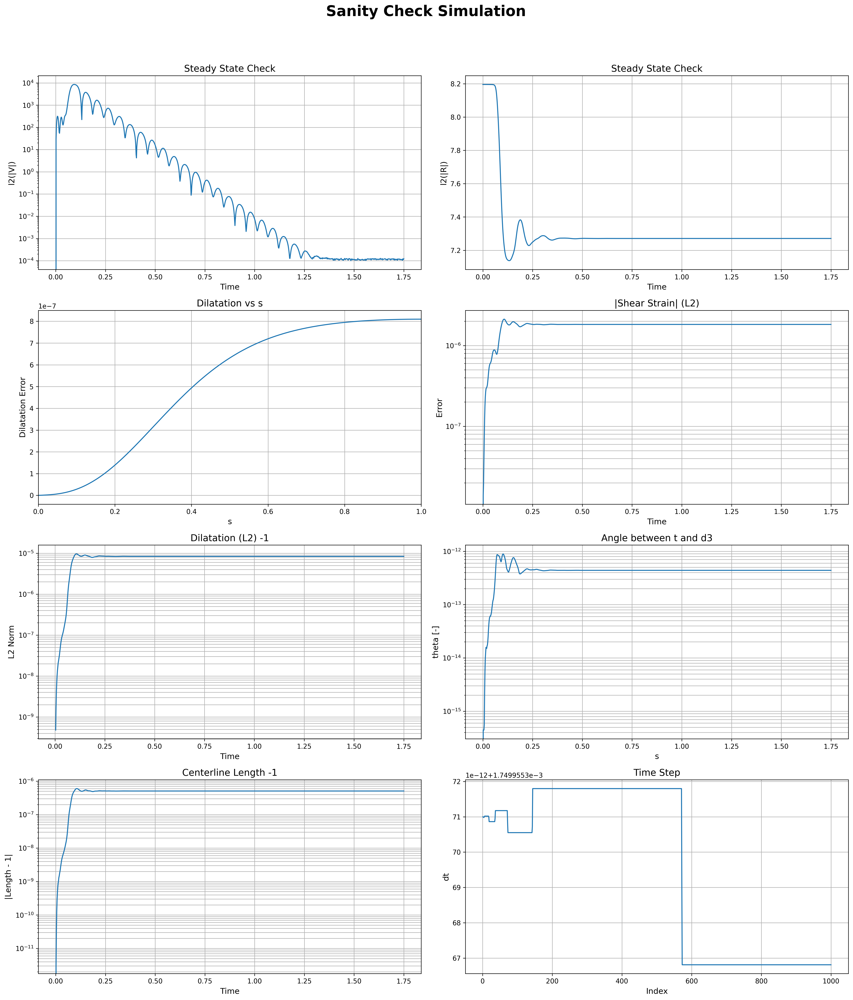

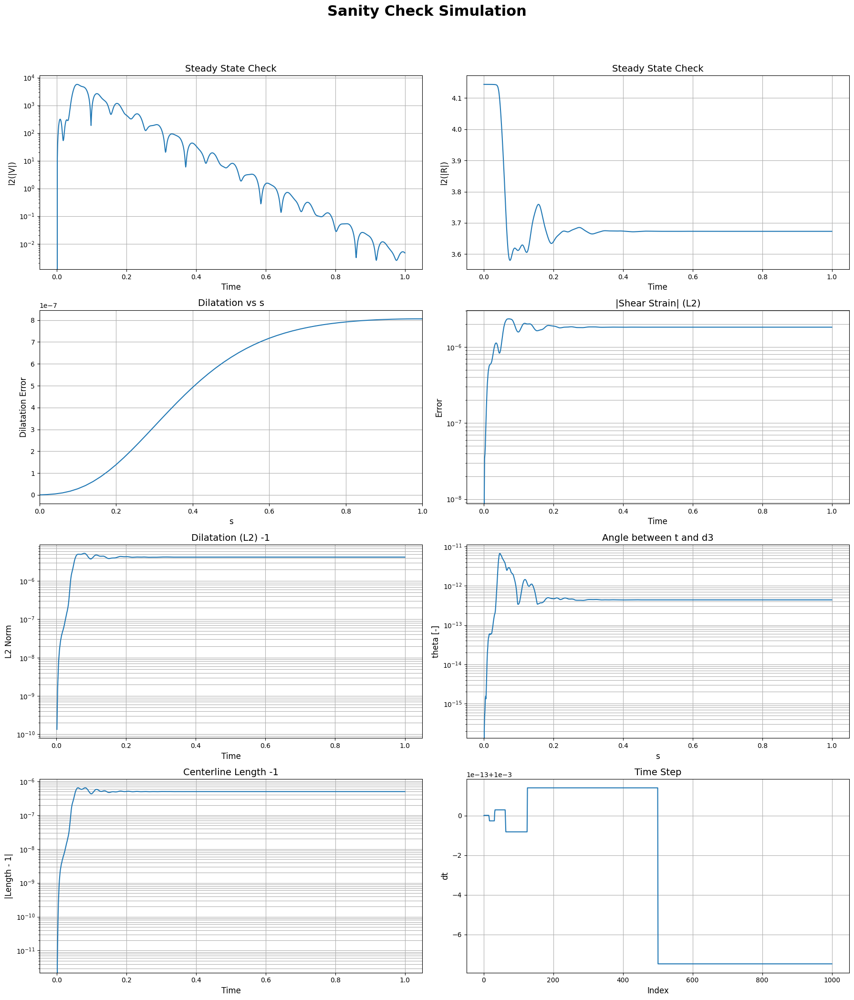

Final stress stat at s = 0:
R1: 8.6564e-03
R2: 8.6562e-01
R3: -4.7308e-07
Final stress stat at s = 1:
R1: 1.8714e-01
R2: 3.9387e-01
R3: 7.4782e-01


In [18]:
sanity_check_plot(solution_1)

### 3D visualization

Here is a 3D interactive visualization. Keep the number of ribbon (size of `indices_array`) small enough to avoid lagging.

In [19]:
fig = plot_3D_ribbons_from_process_solution(
    solution_1, solution_indices=indices_array,
    n_arrows = 3,half_width=width/(2*L))

## Compare solutions with Auto + Convergence analysis
In this section we will do a convergence analysis on the torsional buckling case to illustrate how we can then compare the results obtain in **elastica** with the results from **Auto-07P**.

### Run convergence analysis simulation 

First is a small code to remind the conversion rules between forces in Newton (**elastica**) and adimentional forces (**Auto-07P**). You can find futher explanation on the `AUTO-strip-documentation.pdf` file by Basile Audoly.

In [33]:
Y = 2.77e3
a = 5
t = 0.5
L = 50

force_newton = np.array([0.0, 1.0e-4, 1.0e-4])
force_adimentional = force_newton / (Y * a * t**3 / 12 / L**2)
print(f"{force_newton} in Newton in elastica correspond to {force_adimentional} in Auto")

force_adimentional = np.array([0.0, 0.15, 15])
force_newton = force_adimentional * (Y * a * t**3 / 12 / L**2)

print(f"{force_adimentional} in Auto (adimentional) correspond to {force_newton} in Newton in elastica")

[0.     0.0001 0.0001] in Newton in elastica correspond to [0.         0.00173285 0.00173285] in Auto
[ 0.    0.15 15.  ] in Auto (adimentional) correspond to [0.         0.00865625 0.865625  ] in Newton in elastica


The next cell illustrate how we perform the convergence analysis. The exact same logic is used inside of the python script `run_torsional_buckling.py` that would need to be run on a cluster. It is basically a condense way of doing everything explained on the section: **Simulation initialization: Torsional buckling case**. The only added feature is the *while* loop that relunch the simulation with a smaller **dt** if it diverges.

As a reminder, you can download solution from the cluster with **scp** function: 

`scp -r pmaillar@jed.hpc.epfl.ch:/home/pmaillar/Ribbon_interaction/result Ribbon_interaction_pyelastica/Ribbon_interaction`


In [35]:
direction = np.array([1,0,0])
normal = np.array([0,1,0])

final_time = 0.1 #this would be to low to be sure to converge to steady stat
all_n_elem = np.array([5,10,20]) #list of the number of elements used to descritiezed to ribbon
initial_dt = 2e-7


for idx, n_elem in enumerate(all_n_elem):
    
    dt = initial_dt 
    d1_initial = np.repeat(normal.reshape(3, 1), n_elem, axis=1)
    initial_position = np.array([np.linspace(0,1,n_elem+1)*L,np.zeros(n_elem+1),np.zeros(n_elem+1)])
    

    running = True
    while running:

        #compact function to create the simulation class corresponding to the torsional buckling case
        ribbon_output_list, Ribbon_sim = create_env_torsional_buckling(initial_position, d1_initial, dt = dt, 
                                                                       tip_force = force_newton, ramp_up_time = 0.05, nu = 3e1,
                                                                        base_length = L, thickness = t, width = a, 
                                                                        E = Y, poisson_ratio = 0.34, density = 1.017e-7, 
                                                                        final_time = final_time)
        timestepper = PositionVerlet()
        total_steps = int(final_time / dt)
        nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)
        
        if nan_detected:
            dt /=1.2
            print("New dt:",dt)
        else:
            running = False
            
        if dt<=1e-9:
            running = False
            print("dt set below tolerance. Break simulation")

        #save the data
        with open(f"result/torsional_buckling_demo_{idx}.pickle", 'wb') as handle:
            pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
    

  0%|          | 1096/500000 [00:00<00:25, 19381.48it/s]


NaN detected at step 1096 in system.
Final time of simulation is :  0.0002194000000000045
New dt: 1.6666666666666668e-07


  0%|          | 1102/600000 [00:00<00:39, 15197.50it/s]


NaN detected at step 1102 in system.
Final time of simulation is :  0.00018383333333333278
New dt: 1.388888888888889e-07


100%|██████████| 720000/720000 [00:51<00:00, 14073.69it/s]


...

NaN detected at step 171 in system.
Final time of simulation is :  3.4399999999999996e-05
New dt: 1.6666666666666668e-07


  0%|          | 172/600000 [00:00<00:52, 11465.49it/s]


NaN detected at step 172 in system.
Final time of simulation is :  2.883333333333327e-05
New dt: 1.388888888888889e-07


100%|██████████| 720000/720000 [00:55<00:00, 12860.76it/s]

Final time of simulation is :  0.10000000000058185


### Plot convergence analysis simulation
To plot the convergence analysis, we first compute the error vector between the solution from **Auto-07P** and the solution from **elastica**. To do so, the function `compute_error_vector()` interpolate the **elastica** solution to have the same number of points in each solution and then simply compute the difference bewteen the 2 postion vectors. 
If you want to generate your own **Auto-07P** solution, please follow the guide on the `Noto_guide_Auto.ipynb` notebook.

Plot saved to: convergence_analysis.png


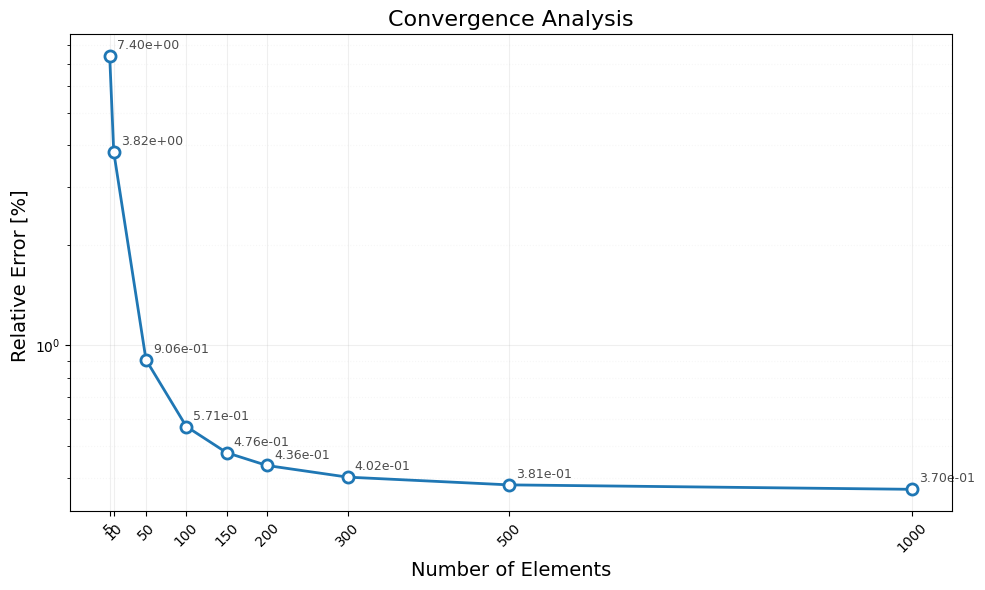

In [36]:
# Read auto solution
solutions_auto = pd.read_csv('solution_auto.csv')
#select the last solution of the continuation analysis of Auto
last_solution_auto = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]

L = 50 #Length of the ribbon inside of elastica [mm]
#all_n_elem = np.array([5, 10, 50, 100, 150, 200, 300, 500, 1000]) #you can use this array if you download all of the solution from the cluster
all_n_elem = np.array([5,10,20])
rel_error = []


for i, n_elem in enumerate(all_n_elem):
    with open(f"result/torsional_buckling_data_{i}.pickle", 'rb') as handle:
        pp_list_read = pickle.load(handle)
    
    solution_elastica = process_solution_elastica(pp_list_read, base_length=L)
    #select the last solution of the dynamic relaxation of elastica (steady stat)
    last_solution_elastica = solution_elastica[solution_elastica.Index_solution == solution_elastica.Index_solution.max()]
    
    error_vectors, _ = compute_error_vector(last_solution_auto, last_solution_elastica)
    #As the total length of the ribbon is 1 and all element avec the same size. 
    #Tacking the mean fo the error_vectors norm is equivalent 
    #to integrating the error norm along the centerline
    rel_error.append(100*np.mean(np.linalg.norm(error_vectors, axis=1)))


#plotting functions
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(all_n_elem, rel_error, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
        markerfacecolor='white', markeredgewidth=2)
ax.set_yscale('log')
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.grid(True, which="minor", ls=":", alpha=0.1)
ax.set_xlabel('Number of Elements', fontsize=14)
ax.set_ylabel('Relative Error [%] ', fontsize=14)
ax.set_title('Convergence Analysis', fontsize=16)
plt.xticks(all_n_elem, rotation=45)
for i, (x, y) in enumerate(zip(all_n_elem, rel_error)):
    ax.annotate(f'{y:.2e}', xy=(x, y), xytext=(5, 5), textcoords='offset points', 
                fontsize=9, alpha=0.7)
plt.tight_layout()
fig.savefig("convergence_analysis.png", bbox_inches='tight', dpi=300)
print(f"Plot saved to: convergence_analysis.png")
plt.show()

## Inspect and compare solutions from elastica and Auto-07P
This section contains all of the code that we use to inspect, debug and asses the quality of the simulations of elastica compare to **Auto-07P**. This is not mendatory to generate the results but might be usefull if you need easy to run code to debug of inspect futher the quality of **elastica** simulations.

Let's first choose a specific solution 

In [81]:
Y = 2.77e3
a = 5
t = 0.5
L = 50

with open("result/torsional_buckling_data_6.pickle", 'rb') as handle:
    pp_list_read = pickle.load(handle)
solutions_elastica = process_solution_elastica(pp_list_read,base_length=base_length)

solutions_auto = pd.read_csv('solution_auto.csv')
solution_auto_unique = solutions_auto[solutions_auto.Index_solution == solutions_auto.Index_solution.max()]
solution_elastica_unique = solutions_elastica[solutions_elastica.time==solutions_elastica.time.max()]

#convert [N] forces into adimentional force to compare with Auto
solution_elastica_unique[["R1","R2","R3"]] = solution_elastica_unique[["R1","R2","R3"]]/(Y * a * t**3 / 12 / L**2)

C:\Users\pmaillar\AppData\Local\Temp\ipykernel_21432\237969778.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



The 2 following cells plots the solution separately. Feel free to change the `solution_indices` parameter.

In [64]:
fig = plot_3D_ribbons_from_process_solution(
    solutions_elastica, solution_indices=[solutions_elastica.Index_solution.max()],
    n_arrows = 3,half_width=0.1)

In [65]:
fig = plot_3D_ribbons_from_process_solution(
    solutions_auto, solution_indices=[solutions_auto.Index_solution.max()],
    n_arrows = 3,half_width=0.1)

The next 3D plot is a superposition of the 2 solution. Keep the number of indices to plot law for visibility.

In [57]:
#the value of s controle the color on the following plots so feel free to play with it to get a nice contrast.
solutions_auto.s = 1
solutions_elastica.s = 1

plot = plot_3D_ribbons_from_process_solutions(solutions_auto, [solutions_auto.Index_solution.max()], solutions_elastica, [solutions_elastica.Index_solution.max()], 
                                           n_points=20, half_width=0.1, n_arrows=2,  color_df1 = 'twilight', color_df2 = 'hsv')

The next 3 cells are 2D plots the compare some unique parameters.

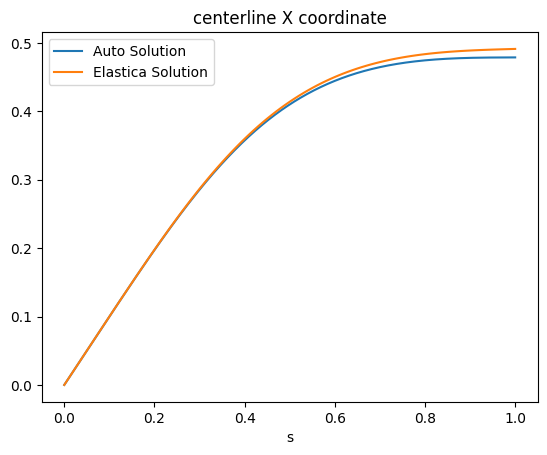

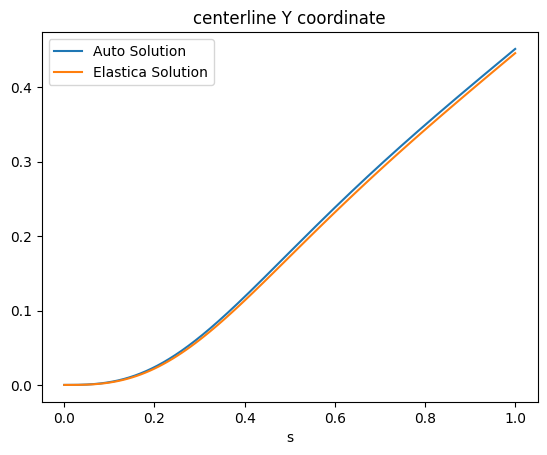

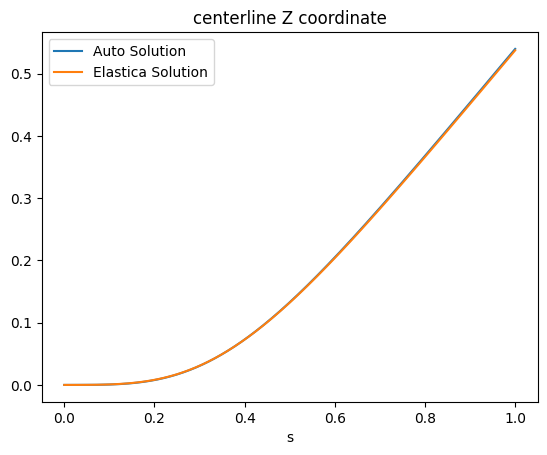

relative error on X at the tip: 2.5909132005862308 %
relative error on Y at the tip: 20.791560168816776 %
relative error on Z at the tip: 19.030288980327178 %


In [72]:
fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='X', ax=ax, label='Auto Solution', title = 'centerline X coordinate')
solution_elastica_unique.plot(x='s', y='X', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Y', ax=ax, label='Auto Solution', title = 'centerline Y coordinate')
solution_elastica_unique.plot(x='s', y='Y', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='Z', ax=ax, label='Auto Solution', title = 'centerline Z coordinate')
solution_elastica_unique.plot(x='s', y='Z', ax=ax, label='Elastica Solution')

plt.show()



print("relative error on X at the tip:", 100*abs(solution_auto_unique.X.iloc[-1]-solution_elastica_unique.X.iloc[-1])/solution_auto_unique.X.iloc[-1],"%")
print("relative error on Y at the tip:", 100*abs(solution_auto_unique.Z.iloc[-1]-solution_elastica_unique.Y.iloc[-1])/solution_auto_unique.Y.iloc[-1],"%")
print("relative error on Z at the tip:", 100*abs(solution_auto_unique.Y.iloc[-1]-solution_elastica_unique.Z.iloc[-1])/solution_auto_unique.Y.iloc[-1],"%")

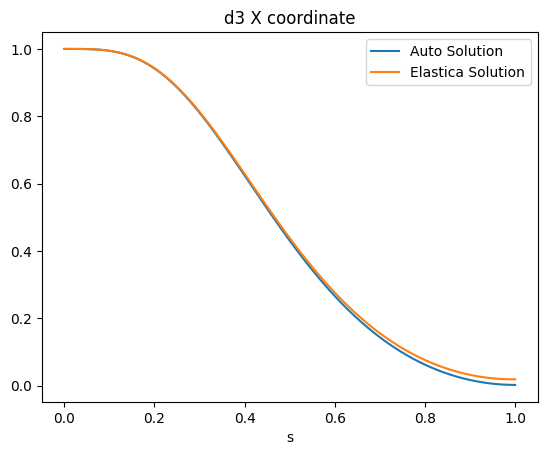

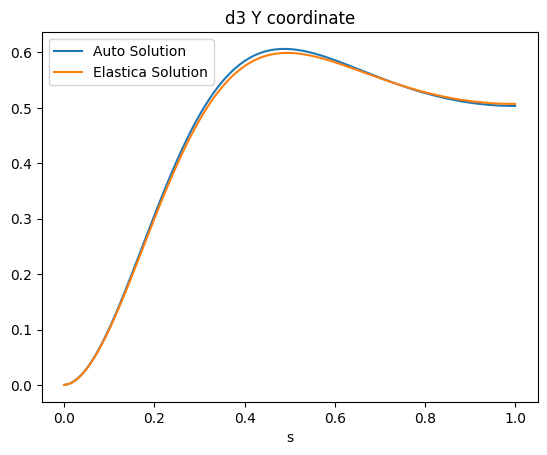

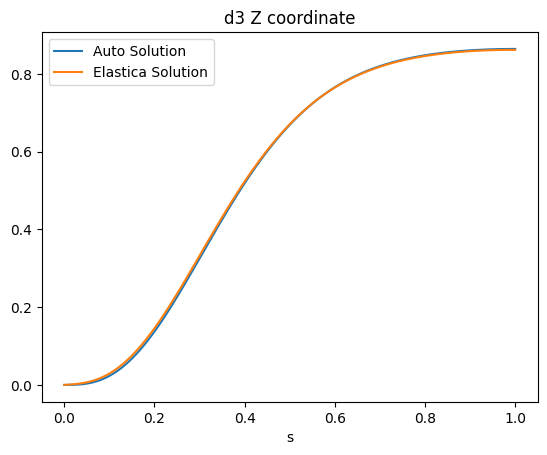

In [73]:
fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3x', ax=ax, label='Auto Solution', title = 'd3 X coordinate')
solution_elastica_unique.plot(x='s', y='d3x', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3y', ax=ax, label='Auto Solution', title = 'd3 Y coordinate')
solution_elastica_unique.plot(x='s', y='d3y', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='d3z', ax=ax, label='Auto Solution', title = 'd3 Z coordinate')
solution_elastica_unique.plot(x='s', y='d3z', ax=ax, label='Elastica Solution')

plt.show()

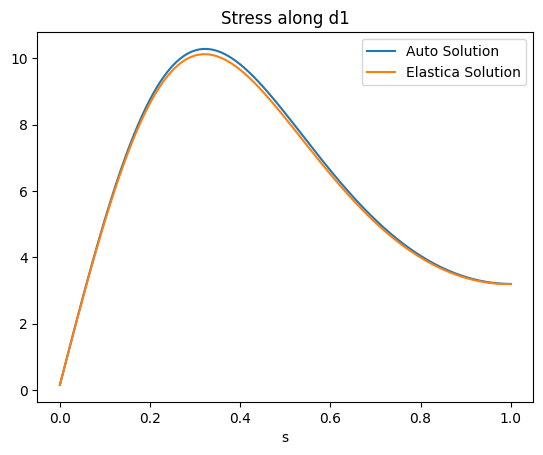

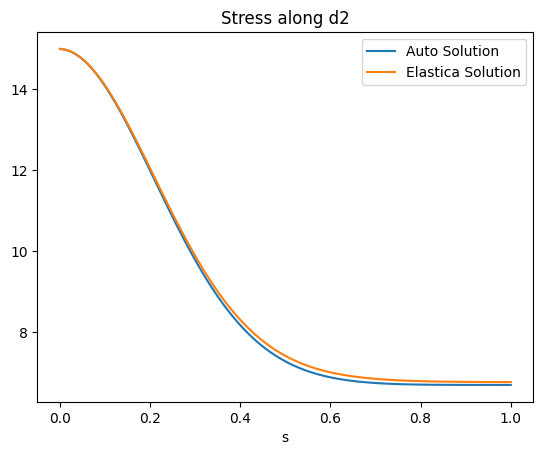

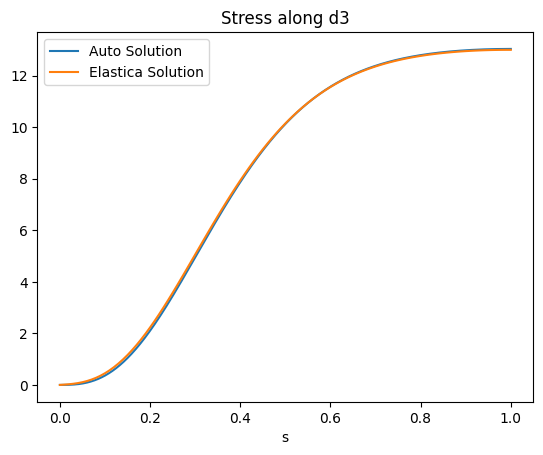

In [75]:
fig, ax = plt.subplots()


solution_auto_unique.plot(x='s', y='R1', ax=ax, label='Auto Solution', title = 'Stress along d1')
solution_elastica_unique.plot(x='s', y='R1', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='R2', ax=ax, label='Auto Solution', title = 'Stress along d2')
solution_elastica_unique.plot(x='s', y='R2', ax=ax, label='Elastica Solution')

plt.show()

fig, ax = plt.subplots()

solution_auto_unique.plot(x='s', y='R3', ax=ax, label='Auto Solution', title = 'Stress along d3')
solution_elastica_unique.plot(x='s', y='R3', ax=ax, label='Elastica Solution')

plt.show()